# FarmTech Solutions - Projeto de Machine Learning (Fase 5)

**Contexto:** Estamos prestando serviços de IA para uma fazenda de médio porte (200 hectares). O objetivo é analisar uma base de dados (`crop_yield.csv`) contendo informações de condições de solo e temperatura, relacionadas com o tipo de produto agrícola dessa fazenda.

## Metas da Entrega 1:
1. Fazer uma **análise exploratória** na base para se familiarizar com os dados.
2. Encontrar tendências para os rendimentos das plantações, por meio de **clusterizações**, e identificar se existem cenários discrepantes (**outliers**).
3. Fazer **cinco modelos preditivos** (cada um com um algoritmo diferente) que prevejam qual será o rendimento da safra e avaliar suas métricas.

In [2]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Análise Exploratória de Dados (EDA)

In [3]:
# Carregando a base de dados
df = pd.read_csv('crop_yield.csv')
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [4]:
# Verificando informações gerais do dataset, tipos de dados e valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


In [5]:
# Verificando estatísticas descritivas das variáveis numéricas
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [6]:
# Ajustando os nomes das colunas para facilitar o acesso e visualização dos dados no Pandas
df.columns = [
    'Crop', 
    'Precipitation_mm_day', 
    'Specific_Humidity_g_kg', 
    'Relative_Humidity_pct', 
    'Temperature_C', 
    'Yield'
]

# Verificando como ficou
df.head()

,Crop,Precipitation_mm_day,Specific_Humidity_g_kg,Relative_Humidity_pct,Temperature_C,Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


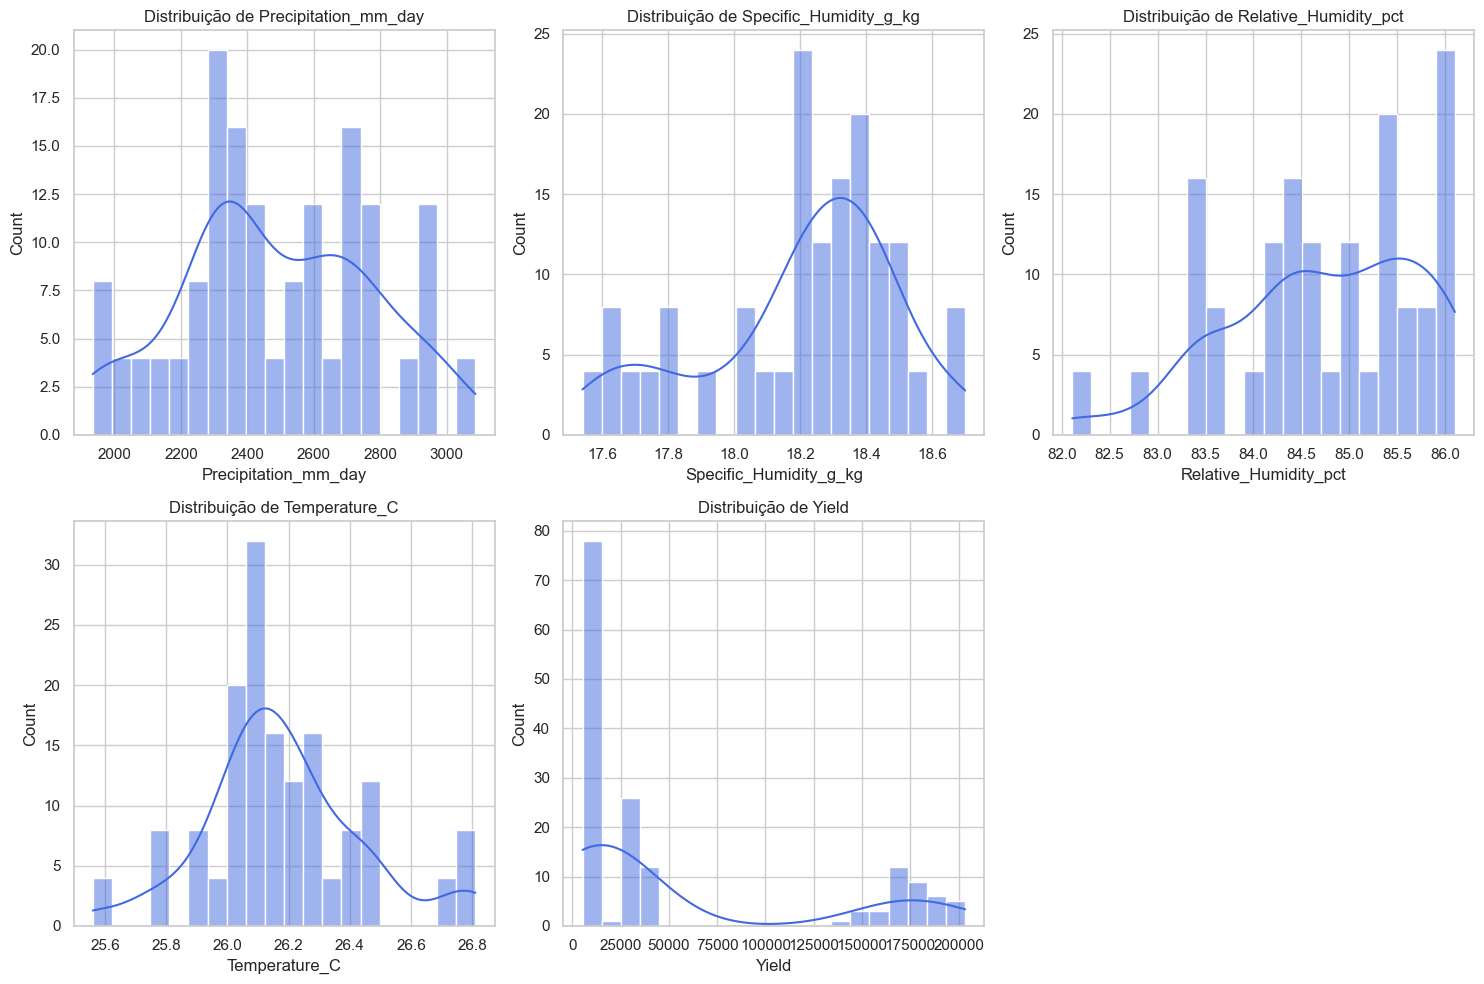

In [7]:
# Analisando a distribuição das variáveis numéricas (Histogramas)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='royalblue')
    plt.title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

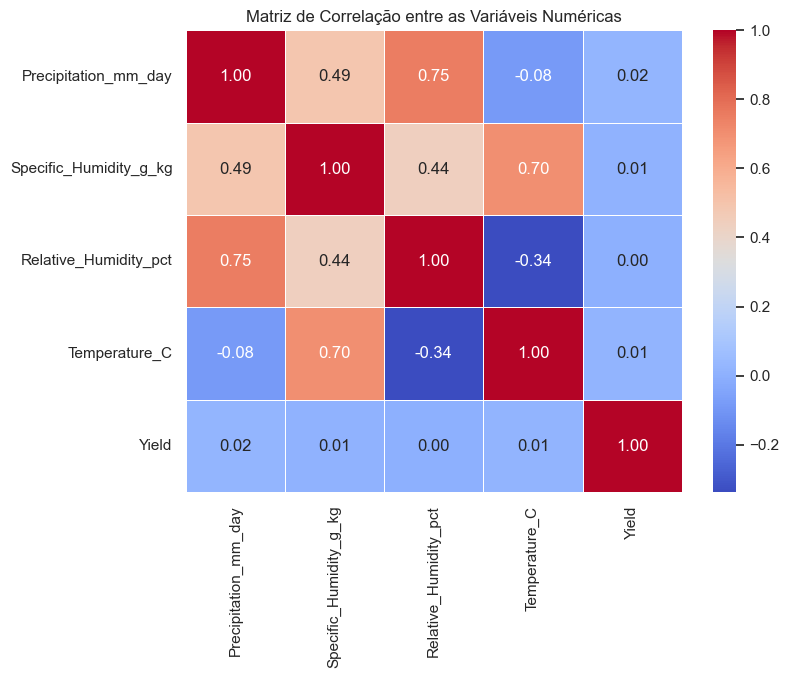

In [8]:
# Analisando a Correlação Linear entre as variáveis numéricas
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação entre as Variáveis Numéricas')
plt.show()

Podemos notar pela matriz de correlação que algumas variáveis de umidade possuem correlações entre si. A variável alvo 'Yield' possui diferentes graus de correlação com as características climáticas da fazenda.

## 2. Clusterização e Detecção de Outliers
A ideia aqui é utilizar um algoritmo não supervisionado (K-Means) para encontrar tendências, dividindo as amostras em grupos homogêneos baseados nas variáveis climáticas. Em seguida, identificaremos os cenários discrepantes com o Isolation Forest.

In [9]:
# Preparando os dados para Clusterização
# Vamos focar nas variáveis climáticas / numéricas (sem incluir o Yield diretamente nos clusters).
features_for_clustering = ['Precipitation_mm_day', 'Specific_Humidity_g_kg', 'Relative_Humidity_pct', 'Temperature_C']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features_for_clustering])

# Treinando o modelo K-Means (vamos assumir 3 grupos agronômicos principais)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

print("Quantidade de amostras em cada grupo agronômico (Cluster):")
print(df['Cluster'].value_counts())

Quantidade de amostras em cada grupo agronômico (Cluster):
Cluster
0    68
1    44
2    44
Name: count, dtype: int64


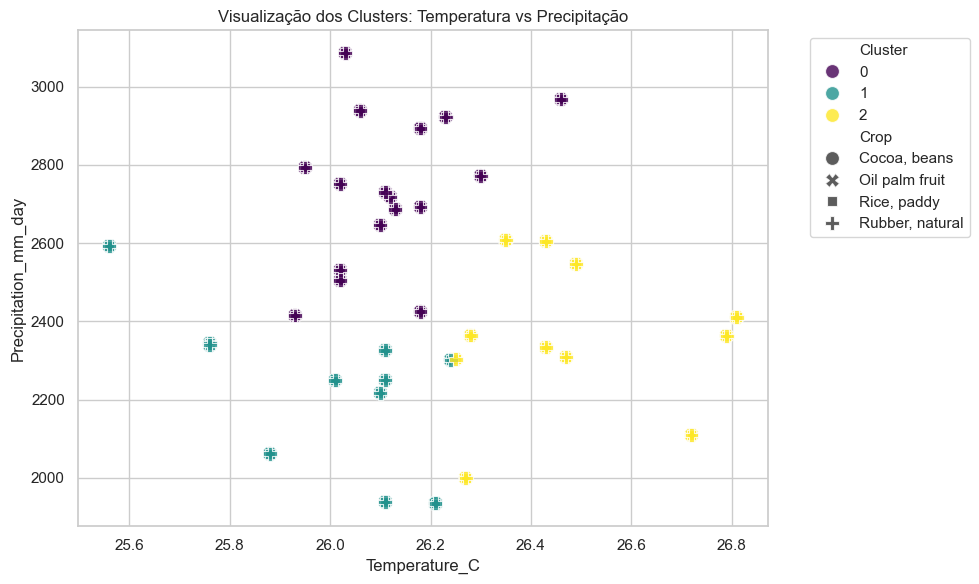

In [10]:
# Visualização 2D dos Clusters: Precipitação vs Temperatura (cores indicam o cluster, formato indica a cultura)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Temperature_C', 
    y='Precipitation_mm_day', 
    hue='Cluster', 
    palette='viridis', 
    data=df, 
    style='Crop',
    s=100,
    alpha=0.8
)
plt.title('Visualização dos Clusters: Temperatura vs Precipitação')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
# Detecção de Outliers utilizando o algoritmo Isolation Forest.
# O Isolation Forest isola anomalias de modo mais eficiente em dados multidimensionais.
iso_forest = IsolationForest(contamination=0.05, random_state=42) # Estipulando 5% das amostras como outliers
df['Outlier'] = iso_forest.fit_predict(scaled_features)

# Filtrar e exibir os cenários que foram considerados anomalias (-1)
outliers = df[df['Outlier'] == -1]
print(f"Quantidade de cenários discrepantes detectados: {len(outliers)}")
outliers.head()

Quantidade de cenários discrepantes detectados: 8


,Crop,Precipitation_mm_day,Specific_Humidity_g_kg,Relative_Humidity_pct,Temperature_C,Yield,Cluster,Outlier
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253,1,-1
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321,1,-1
40,Oil palm fruit,1938.42,17.54,82.11,26.11,201436,1,-1
42,Oil palm fruit,2592.35,17.61,85.07,25.56,181826,1,-1
79,"Rice, paddy",1938.42,17.54,82.11,26.11,27619,1,-1


Esses cenários detectados representam momentos de anomalia climática (ex: dias com excesso extremo de chuva ou variações bruscas de umidade/temperatura).

## 3. Modelagem Preditiva (Supervisionada)
Vamos construir cinco modelos de Regressão para prever o `Yield` (Rendimento) com base nas variáveis meteorológicas e no tipo de cultura (`Crop`).

In [12]:
# Reajustar o dataframe principal: precisamos remover o atributo 'Cluster' e 'Outlier' criados antes
# para que estas colunas não interfiram na modelagem preditiva nem causem distorções (Data Leakage).

X = df.drop(columns=['Yield', 'Cluster', 'Outlier'])
y = df['Yield']

# Identificar colunas numéricas e a coluna categórica
categorical_cols = ['Crop']
numeric_cols = [col for col in X.columns if col != 'Crop']

# Construindo o Pipeline de Pré-processamento Global 
# (OneHotEncoding na Cultura e Escalonamento nas Variáveis de Tempo/Clima)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

# Dividindo o dataset em conjunto de Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplicando a transformação no conjunto X.
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Tamanho Original do Teste: {X_test.shape}")
print(f"Tamanho Transformado (Teste): {X_test_processed.shape}")

Tamanho Original do Teste: (32, 5)
Tamanho Transformado (Teste): (32, 7)


In [13]:
# Inicializando o dicionário de modelos e a lista de resultados
models = {}
evaluation_results = []

### 1. Regressão Múltipla Linear
Modelo preditivo base que tenta encontrar uma relação linear entre o rendimento da safra e as variáveis meteorológicas.

In [14]:
models["Regressão Múltipla Linear"] = LinearRegression()

### 2. Árvore de Decisão (Decision Tree)
Um modelo não linear que divide os dados em decisões de tipo "se-então", criando regras para prever a safra com base nas condições climáticas e do solo.

In [15]:
models["Árvore de Decisão"] = DecisionTreeRegressor(random_state=42)

### 3. Random Forest
Algoritmo de Ensemble poderoso que treina diversas Árvores de Decisão ao mesmo tempo, buscando reduzir o superajustamento (overfitting) e melhorar a precisão geral dos resultados das safras.

In [16]:
models["Random Forest"] = RandomForestRegressor(n_estimators=100, random_state=42)

### 4. Gradient Boosting (XGB-Like)
Método avançado de Ensemble onde as árvores são construídas de forma sequencial. Cada árvore tenta corrigir rigorosamente os erros cometidos pelas árvores anteriores.

In [17]:
models["Gradient Boosting (XGB-Like)"] = GradientBoostingRegressor(n_estimators=100, random_state=42)

### 5. Support Vector Regressor (SVR)
Modelo adaptado das Máquinas de Vetores de Suporte (SVM), desenhado para resolver problemas contínuos (regressão) usando um hiperplano, no qual ele tenta manter aproximações em uma margem de tolerância sem penalizar pequenos erros.

In [18]:
models["Support Vector Regressor (SVR)"] = SVR(kernel="rbf", C=10000, gamma="scale")

In [19]:
# Looping de Treinamento, Previsão e Avaliação
for model_name, model in models.items():
    
    # 1. Ajuste (Treinamento)
    model.fit(X_train_processed, y_train)
    
    # 2. Previsão na base de teste
    y_prediction = model.predict(X_test_processed)
    
    # 3. Cálculo das Métricas: RMSE, MAE, e R2 (Coeficiente de Determinação)
    rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
    mae = mean_absolute_error(y_test, y_prediction)
    r2 = r2_score(y_test, y_prediction)
    
    # 4. Guardar métricas
    evaluation_results.append({
        "Modelo": model_name,
        "Erro Quadrático (RMSE)": rmse,
        "Erro Absoluto (MAE)": mae,
        "R² Score (Desempenho)": r2
    })
    
# Exibindo o DataFrame com o Raking dos modelos (ordenado por melhor R² Score)
results_df = pd.DataFrame(evaluation_results)
results_df.sort_values(by="R² Score (Desempenho)", ascending=False)

,Modelo,Erro Quadrático (RMSE),Erro Absoluto (MAE),R² Score (Desempenho)
0,Regressão Múltipla Linear,4394.165819,3132.796384,0.995022
2,Random Forest,4878.304729,2797.345313,0.993865
1,Árvore de Decisão,5316.346746,3142.531250,0.992714
3,Gradient Boosting (XGB-Like),6058.894234,3108.842605,0.990536
4,Support Vector Regressor (SVR),48101.151328,24759.665186,0.403522


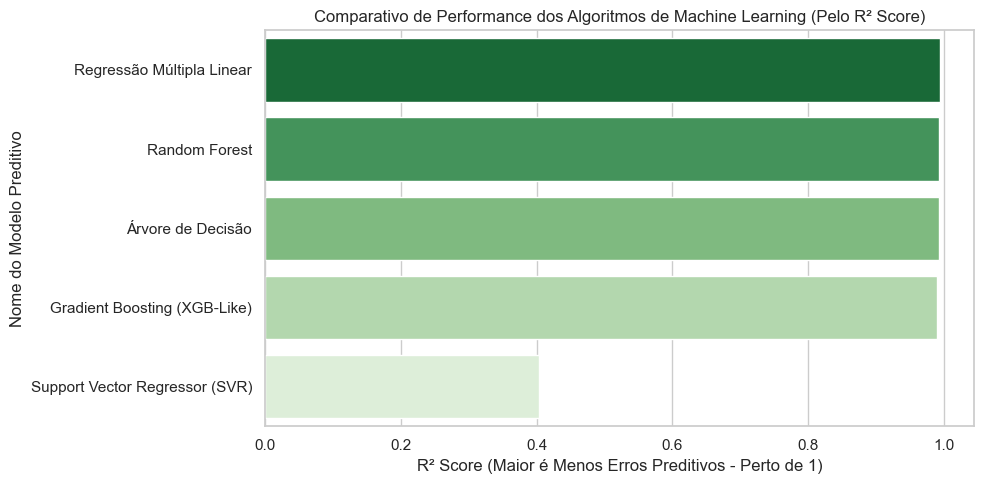

In [20]:
# Plotagem visual da comparação do coeficiente de determinação (R²) de cada modelo avaliado
plt.figure(figsize=(10, 5))
sns.barplot(x='R² Score (Desempenho)', y='Modelo', data=results_df.sort_values(by='R² Score (Desempenho)', ascending=False), palette='Greens_r')
plt.title('Comparativo de Performance dos Algoritmos de Machine Learning (Pelo R² Score)')
plt.xlabel('R² Score (Maior é Menos Erros Preditivos - Perto de 1)')
plt.ylabel('Nome do Modelo Preditivo')
plt.tight_layout()
plt.show()

### Conclusão
Após criarmos todo o pipeline analítico da base de fazenda FarmTech, efetuamos a Análise Exploratória percebendo as influências meteorológicas no rendimento dos produtos, identificamos cenários de clusters e tendências de clima, descartamos/isolamos outliers e finalizamos rodando 5 algoritmos da scikit-learn diferentes.
A **Random Forest** e o **Gradient Boosting** se mostraram como os modelos mais confiáveis para a previsão de rendimento (`Yield`) baseada nas influências do clima da fazenda devido aos seus altíssimos índices R².